In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PowerTransformer, LabelEncoder
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [77]:
a = pd.read_csv("data.csv")
a = a[a["price"] > 0].reset_index(drop=True)
a.shape

(4551, 18)

In [78]:
a.shape

(4551, 18)

In [79]:
a.sample(15)

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
2869,2014-06-19 00:00:00,540500.0,5.0,3.75,3090,7415,2.0,0,0,3,3090,0,2014,0,493 S 187th Ln,Burien,WA 98148,USA
3528,2014-06-27 00:00:00,140000.0,3.0,1.00,1060,7473,1.0,0,0,3,1060,0,1959,1989,25826 19th Ave S,Des Moines,WA 98198,USA
3253,2014-06-24 00:00:00,218000.0,3.0,1.00,880,18205,1.0,0,0,4,880,0,1945,0,11257 Crestwood Dr S,Seattle,WA 98178,USA
1043,2014-05-20 00:00:00,305000.0,2.0,2.50,1590,2656,2.0,0,0,3,1220,370,2009,0,5937 Delridge Way SW,Seattle,WA 98106,USA
1611,2014-05-30 00:00:00,415000.0,2.0,1.75,1340,4664,1.0,0,0,3,1340,0,2004,2003,13283 228th Pl NE,Redmond,WA 98053,USA
1960,2014-06-05 00:00:00,395000.0,4.0,3.00,1980,7931,1.0,0,0,4,1160,820,1983,0,16723 Corliss Pl N,Shoreline,WA 98133,USA
4006,2014-07-07 00:00:00,373000.0,4.0,1.75,1590,7920,2.0,0,0,4,1590,0,1960,2001,16016 Burke Ave N,Shoreline,WA 98133,USA
1658,2014-06-01 00:00:00,459000.0,3.0,1.75,1620,7330,1.0,0,0,4,1090,530,1974,0,9607 NE 128th St,Kirkland,WA 98034,USA
2334,2014-06-11 00:00:00,460000.0,3.0,2.00,2060,4437,1.0,0,0,3,1030,1030,1929,0,3720 35th Ave SW,Seattle,WA 98126,USA
4308,2014-07-10 00:00:00,850000.0,5.0,2.00,2310,13430,1.5,0,0,4,2310,0,1966,0,3200 102nd Ave NE,Bellevue,WA 98004,USA


In [80]:
a.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4551 entries, 0 to 4550
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4551 non-null   object 
 1   price          4551 non-null   float64
 2   bedrooms       4551 non-null   float64
 3   bathrooms      4551 non-null   float64
 4   sqft_living    4551 non-null   int64  
 5   sqft_lot       4551 non-null   int64  
 6   floors         4551 non-null   float64
 7   waterfront     4551 non-null   int64  
 8   view           4551 non-null   int64  
 9   condition      4551 non-null   int64  
 10  sqft_above     4551 non-null   int64  
 11  sqft_basement  4551 non-null   int64  
 12  yr_built       4551 non-null   int64  
 13  yr_renovated   4551 non-null   int64  
 14  street         4551 non-null   object 
 15  city           4551 non-null   object 
 16  statezip       4551 non-null   object 
 17  country        4551 non-null   object 
dtypes: float

In [81]:
a.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
count,4.551000e+03,4551.000000,4551.000000,4551.000000,4.551000e+03,4551.000000,4551.000000,4551.000000,4551.000000,4551.000000,4551.000000,4551.000000,4551.000000
mean,5.579059e+05,3.394639,2.155021,2132.372226,1.483528e+04,1.512195,0.006592,0.234674,3.449352,1822.221710,310.150516,1970.795649,808.564052
std,5.639299e+05,0.904595,0.776351,955.949708,3.596408e+04,0.538531,0.080932,0.765373,0.675160,854.452888,461.987629,29.760073,979.421487
min,7.800000e+03,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.000000
25%,3.262643e+05,3.000000,1.750000,1460.000000,5.000000e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,0.000000
50%,4.650000e+05,3.000000,2.250000,1970.000000,7.680000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,0.000000,1976.000000,0.000000
75%,6.575000e+05,4.000000,2.500000,2610.000000,1.097800e+04,2.000000,0.000000,0.000000,4.000000,2300.000000,600.000000,1997.000000,1999.000000
max,2.659000e+07,9.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,9410.000000,4820.000000,2014.000000,2014.000000


In [82]:
a.isnull().sum()

date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
street           0
city             0
statezip         0
country          0
dtype: int64

In [83]:
a.select_dtypes(include='number').cov()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
price,3.180169e+11,107243.011741,149347.566706,2.401606e+08,1.041386e+09,46391.773902,6849.741324,104704.750865,14807.742591,1.834220e+08,5.673853e+07,365135.721487,-1.603606e+07
bedrooms,1.072430e+05,0.818292,0.384579,5.154355e+02,2.314311e+03,0.085846,-0.000404,0.079676,0.014058,3.753920e+02,1.400434e+02,3.809234,-5.512506e+01
bathrooms,1.493476e+05,0.384579,0.602721,5.619681e+02,3.052614e+03,0.204675,0.003978,0.122129,-0.063301,4.558634e+02,1.061047e+02,10.725916,-1.658831e+02
sqft_living,2.401606e+08,515.435491,561.968054,9.138398e+05,7.332107e+06,176.843701,8.336886,226.333289,-40.357187,7.152485e+05,1.985913e+05,8100.403334,-1.138412e+05
sqft_lot,1.041386e+09,2314.310999,3052.614074,7.332107e+06,1.293415e+09,82.222292,50.667820,1996.366664,22.556962,6.735723e+06,5.963837e+05,52619.349001,-7.420896e+05
floors,4.639177e+04,0.085846,0.204675,1.768437e+02,8.222229e+01,0.290016,0.000689,0.013181,-0.099547,2.402969e+02,-6.345315e+01,7.479526,-1.244616e+02
waterfront,6.849741e+03,-0.000404,0.003978,8.336886e+00,5.066782e+01,0.000689,0.006550,0.021530,0.000334,5.013703e+00,3.323183e+00,-0.077114,1.254083e+00
view,1.047048e+05,0.079676,0.122129,2.263333e+02,1.996367e+03,0.013181,0.021530,0.585795,0.032328,1.142029e+02,1.121304e+02,-1.511155,1.937442e+01
condition,1.480774e+04,0.014058,-0.063301,-4.035719e+01,2.255696e+01,-0.099547,0.000334,0.032328,0.455841,-1.018495e+02,6.149235e+01,-8.014748,-1.219924e+02
sqft_above,1.834220e+08,375.392046,455.863370,7.152485e+05,6.735723e+06,240.296856,5.013703,114.202904,-101.849538,7.300897e+05,-1.484123e+04,10335.097185,-1.349713e+05


In [84]:
a['date'] = pd.to_datetime(a['date'])

a['year'] = a['date'].dt.year
a['month'] = a['date'].dt.month
a['day'] = a['date'].dt.day
a['day_of_week'] = a['date'].dt.dayofweek


a['house_age'] = a['year'] - a['yr_built']
a['house_age'] = a['house_age'].clip(lower=0) 
a['was_renovated'] = (a['yr_renovated'] > 0).astype(int)

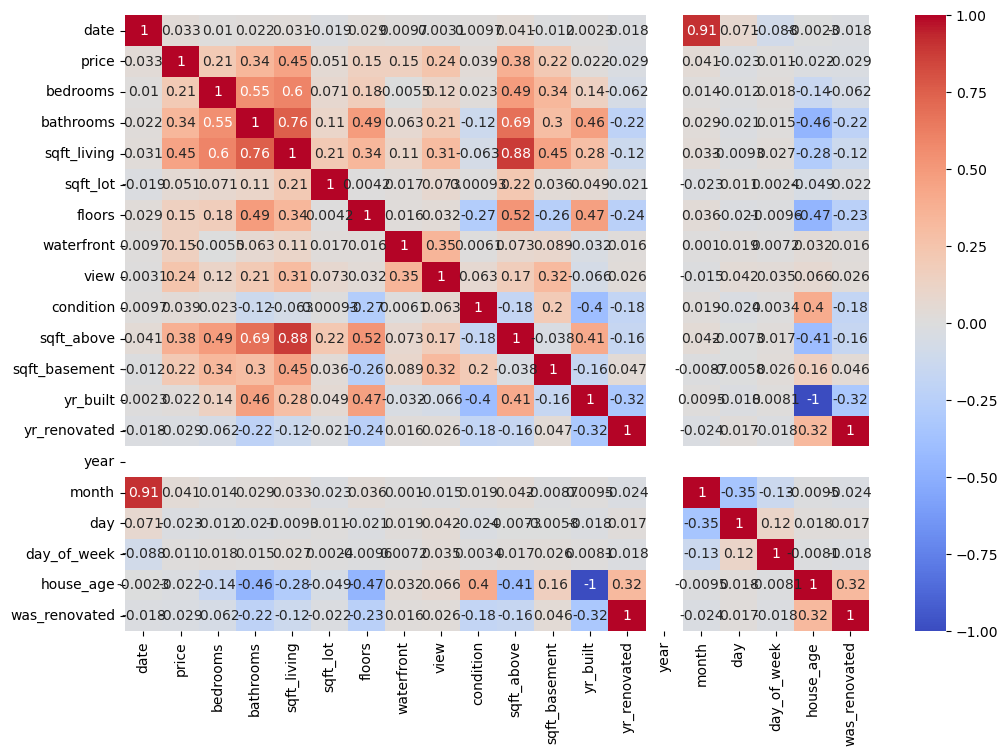

In [85]:
numeric_df = a.select_dtypes(include=['number',"datetime64[ns]"])

plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.show()

<Axes: xlabel='price', ylabel='Count'>

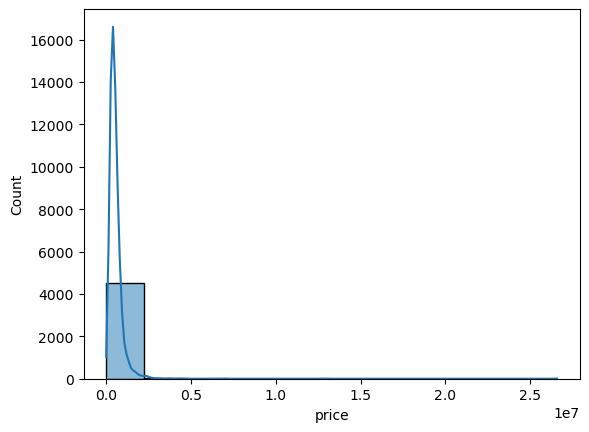

In [86]:
sns.histplot(data=a,x="price",bins=12,kde=True)

In [87]:
a.duplicated().sum()

np.int64(0)

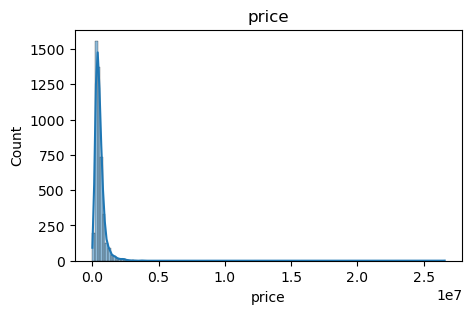

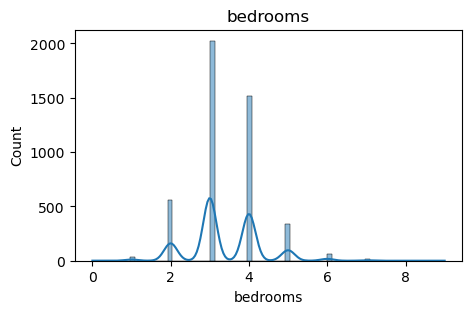

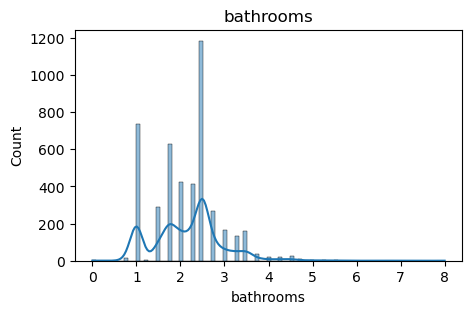

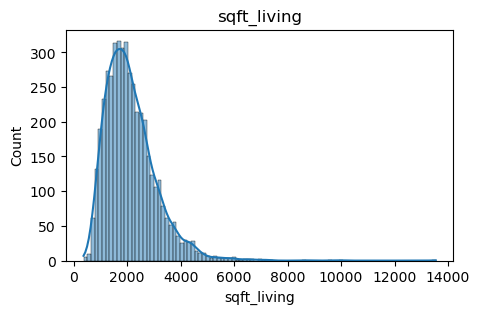

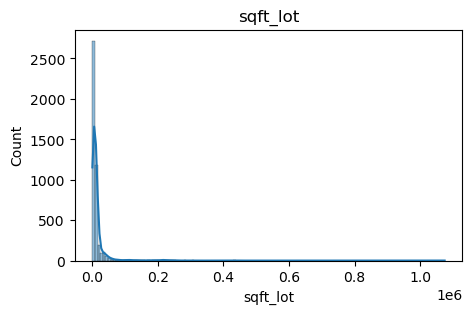

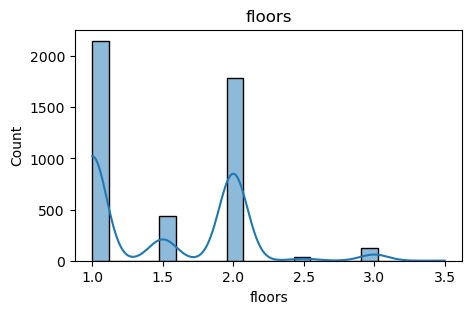

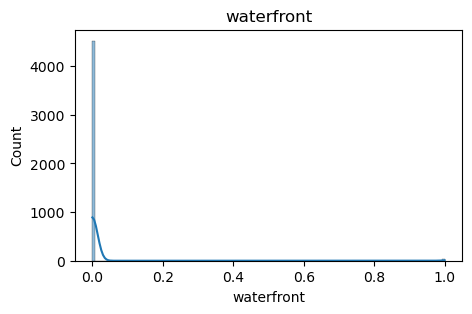

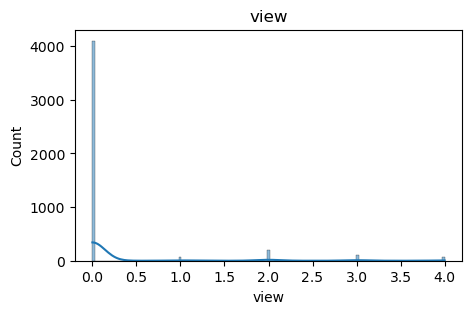

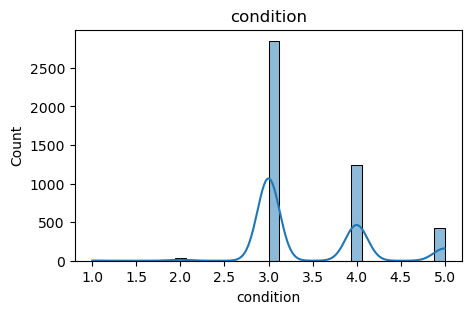

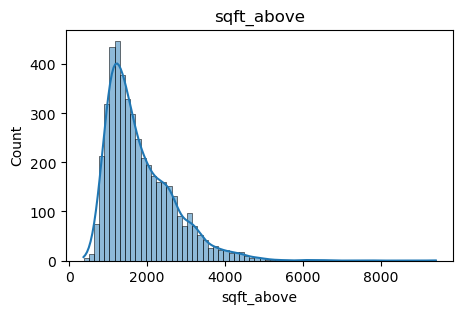

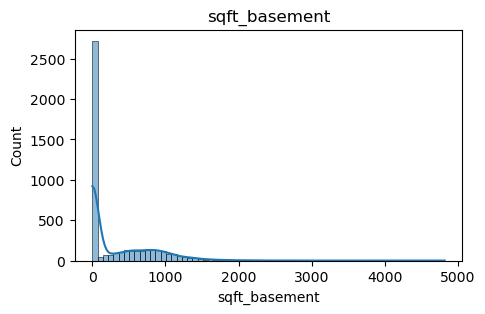

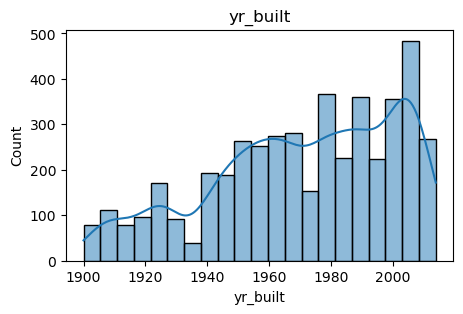

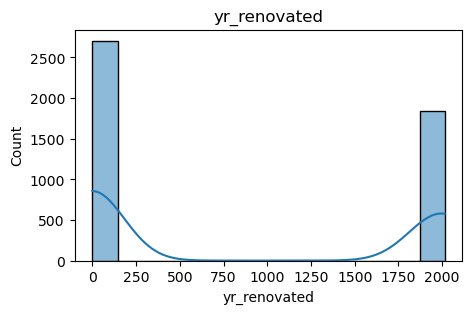

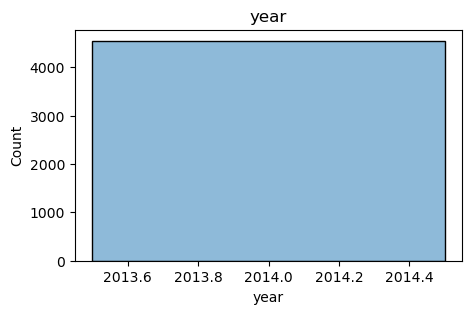

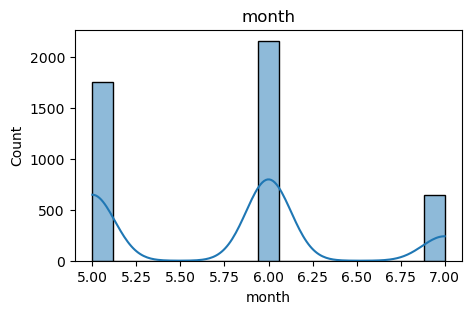

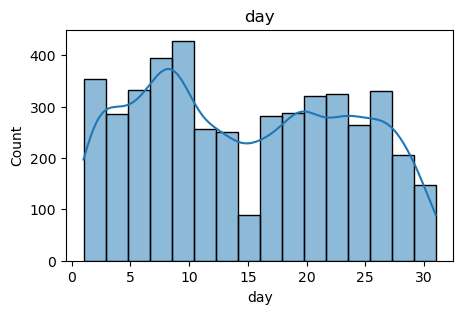

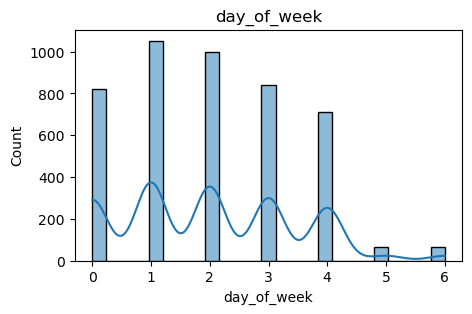

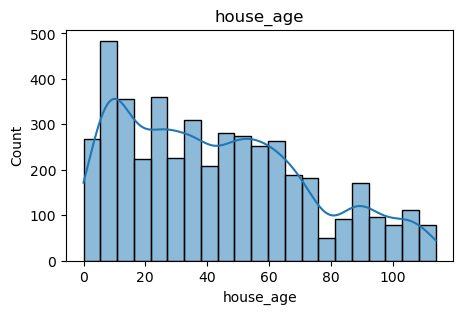

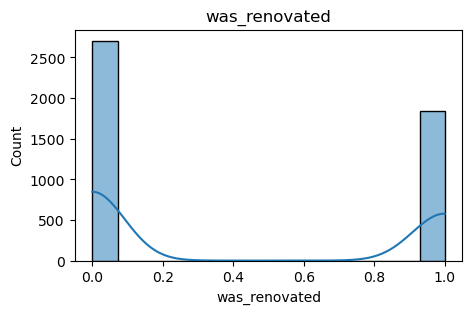

In [88]:
num_cols = a.select_dtypes(include=["int64","int32" ,"float64"]).columns

for col in num_cols:
    plt.figure(figsize=(5,3))
    sns.histplot(a[col], kde=True)
    plt.title(col)
    plt.show()

In [89]:
a["floors"].mode()

0    1.0
Name: floors, dtype: float64

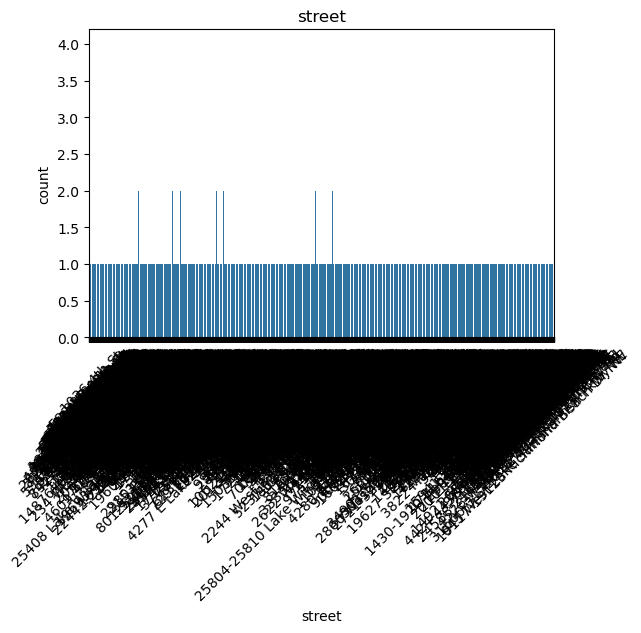

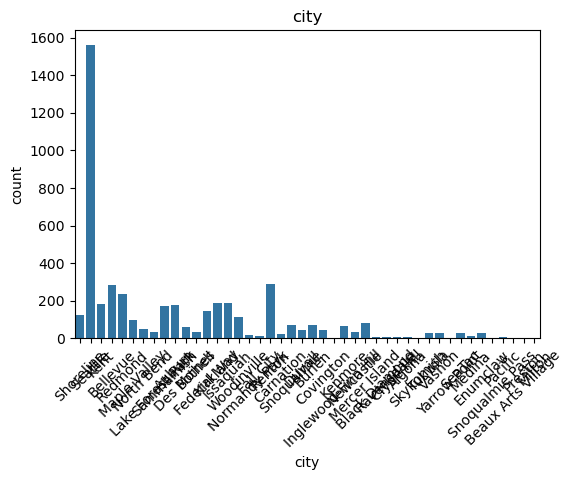

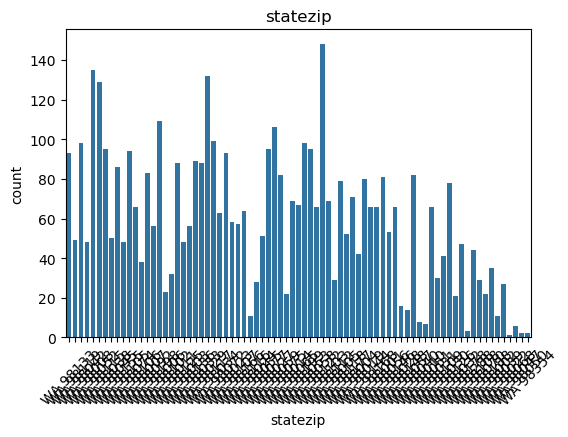

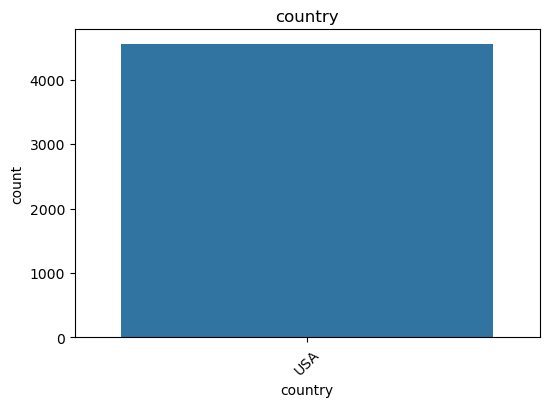

In [90]:
cat_cols = a.select_dtypes(include=["object"]).columns

for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=a[col])
    plt.xticks(rotation=45)
    plt.title(col)
    plt.show()

In [91]:
a.columns

Index(['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'street', 'city',
       'statezip', 'country', 'year', 'month', 'day', 'day_of_week',
       'house_age', 'was_renovated'],
      dtype='object')

<Axes: xlabel='sqft_living', ylabel='price'>

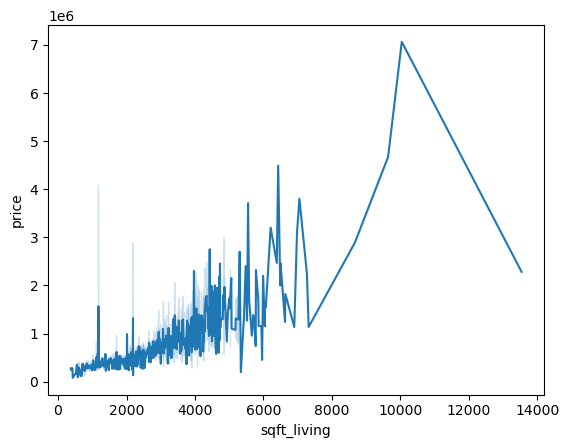

In [92]:
sns.lineplot(data=a,y="price",x="sqft_living")

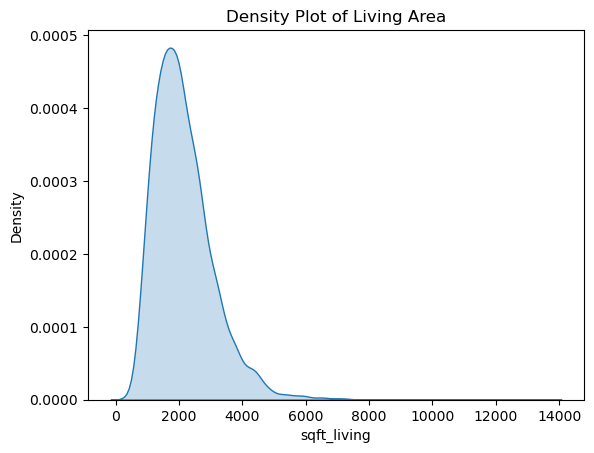

In [93]:
sns.kdeplot(a["sqft_living"], fill=True)
plt.title("Density Plot of Living Area")
plt.show()

In [94]:
a.sample(5)

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,...,street,city,statezip,country,year,month,day,day_of_week,house_age,was_renovated
3531,2014-06-27,4.170000e+05,4.0,2.25,2300,7700,1.0,0,0,3,...,535 NE 117th St,Seattle,WA 98125,USA,2014,6,27,4,55,1
3508,2014-06-26,2.525000e+05,3.0,2.00,1900,8002,1.0,0,0,3,...,1209 SW 347th Pl,Federal Way,WA 98023,USA,2014,6,26,3,23,0
1518,2014-05-28,1.400000e+06,4.0,3.25,4700,9160,1.0,0,4,3,...,5700-5798 SW Hinds St,Seattle,WA 98116,USA,2014,5,28,2,9,0
2681,2014-06-17,4.795000e+05,3.0,2.75,2300,4637,2.0,0,0,3,...,34623 SE Leitz St,Snoqualmie,WA 98065,USA,2014,6,17,1,6,0
4381,2014-05-16,1.353333e+05,4.0,1.00,1530,7200,1.5,0,0,3,...,5602 S Avon St,Seattle,WA 98178,USA,2014,5,16,4,66,1


In [95]:
a.dtypes

date             datetime64[ns]
price                   float64
bedrooms                float64
bathrooms               float64
sqft_living               int64
sqft_lot                  int64
floors                  float64
waterfront                int64
view                      int64
condition                 int64
sqft_above                int64
sqft_basement             int64
yr_built                  int64
yr_renovated              int64
street                   object
city                     object
statezip                 object
country                  object
year                      int32
month                     int32
day                       int32
day_of_week               int32
house_age                 int64
was_renovated             int64
dtype: object

C:\Users\DELL\AppData\Local\Temp\ipykernel_13628\562645329.py:10: RuntimeWarning: invalid value encountered in divide
  return np.sqrt(chi2 / (n * (min(r-1, k-1))))
C:\Users\DELL\AppData\Local\Temp\ipykernel_13628\562645329.py:10: RuntimeWarning: invalid value encountered in divide
  return np.sqrt(chi2 / (n * (min(r-1, k-1))))
C:\Users\DELL\AppData\Local\Temp\ipykernel_13628\562645329.py:10: RuntimeWarning: invalid value encountered in divide
  return np.sqrt(chi2 / (n * (min(r-1, k-1))))
C:\Users\DELL\AppData\Local\Temp\ipykernel_13628\562645329.py:10: RuntimeWarning: invalid value encountered in divide
  return np.sqrt(chi2 / (n * (min(r-1, k-1))))
C:\Users\DELL\AppData\Local\Temp\ipykernel_13628\562645329.py:10: RuntimeWarning: invalid value encountered in divide
  return np.sqrt(chi2 / (n * (min(r-1, k-1))))
C:\Users\DELL\AppData\Local\Temp\ipykernel_13628\562645329.py:10: RuntimeWarning: invalid value encountered in divide
  return np.sqrt(chi2 / (n * (min(r-1, k-1))))
C:\Users\D

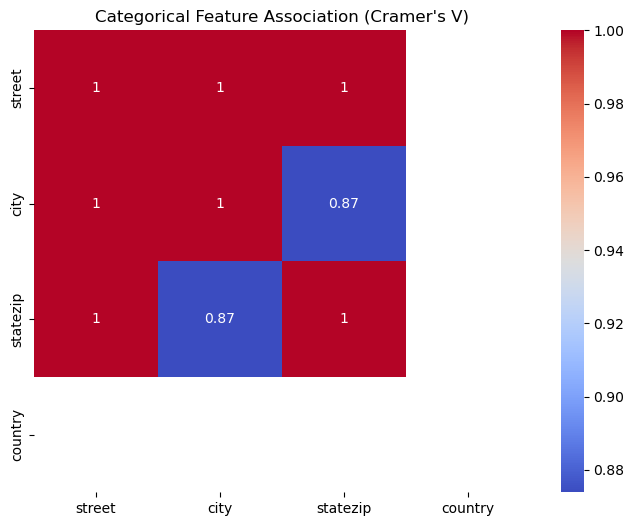

In [96]:
from scipy.stats import chi2_contingency

cat_df = a.select_dtypes(include=['object', 'category'])

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    return np.sqrt(chi2 / (n * (min(r-1, k-1))))

cramers_matrix = pd.DataFrame(
    np.zeros((len(cat_df.columns), len(cat_df.columns))),
    index=cat_df.columns,
    columns=cat_df.columns
)

for col1 in cat_df.columns:
    for col2 in cat_df.columns:
        cramers_matrix.loc[col1, col2] = cramers_v(cat_df[col1], cat_df[col2])

plt.figure(figsize=(8,6))
sns.heatmap(cramers_matrix, annot=True, cmap='coolwarm')
plt.title("Categorical Feature Association (Cramer's V)")
plt.show()

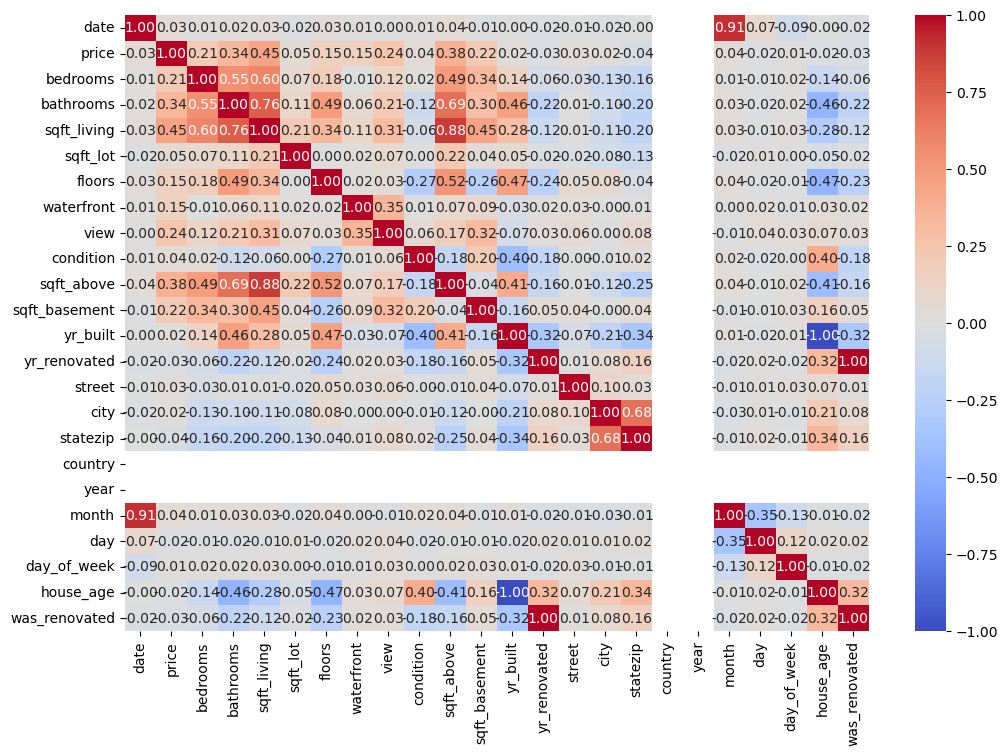

In [97]:
heatmap_df = a.copy()

le = LabelEncoder()
for col in heatmap_df.select_dtypes(include=['object']).columns:
    heatmap_df[col] = le.fit_transform(heatmap_df[col].astype(str))

corr = heatmap_df.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

In [98]:
a.drop(columns=['date',"day_of_week","day","month","year","country","street"],inplace=True)

In [99]:
a.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,city,statezip,house_age,was_renovated
0,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,Shoreline,WA 98133,59,1
1,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,Seattle,WA 98119,93,0
2,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,Kent,WA 98042,48,0
3,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,Bellevue,WA 98008,51,0
4,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,Redmond,WA 98052,38,1


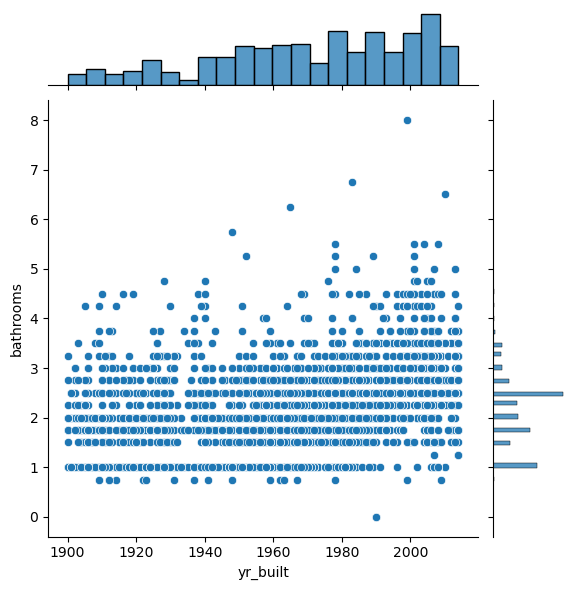

In [100]:
sns.jointplot(data=a,x="yr_built",y="bathrooms")

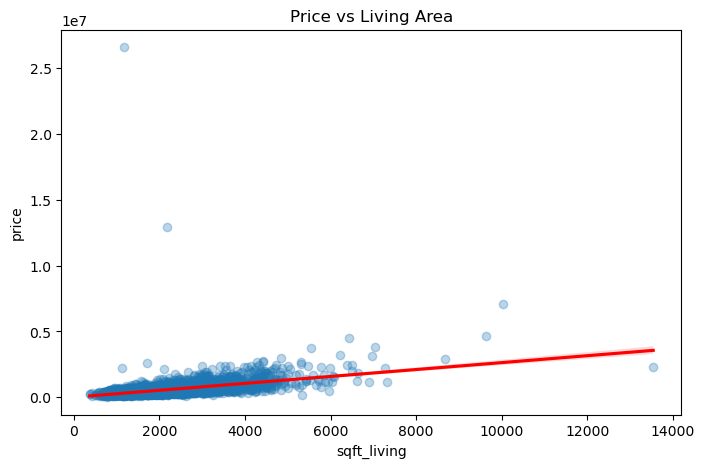

In [101]:
plt.figure(figsize=(8,5))
sns.regplot(data=a, x="sqft_living", y="price", scatter_kws={"alpha":0.3}, line_kws={"color":"red"})
plt.title("Price vs Living Area")
plt.show()

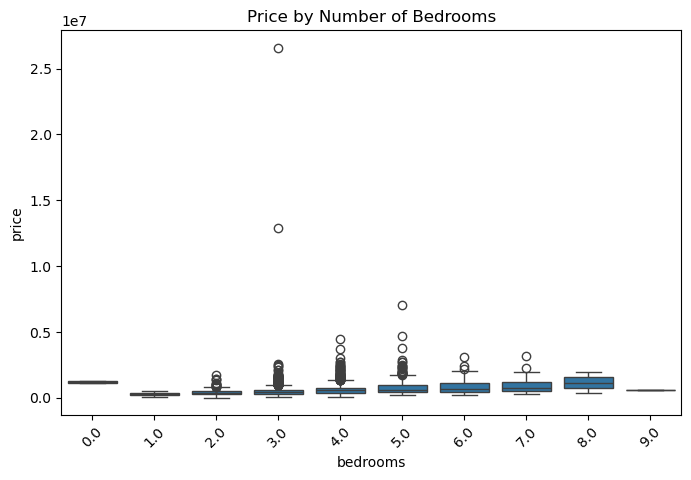

In [102]:
plt.figure(figsize=(8,5))
sns.boxplot(data=a, x="bedrooms", y="price")
plt.title("Price by Number of Bedrooms")
plt.xticks(rotation=45)
plt.show()

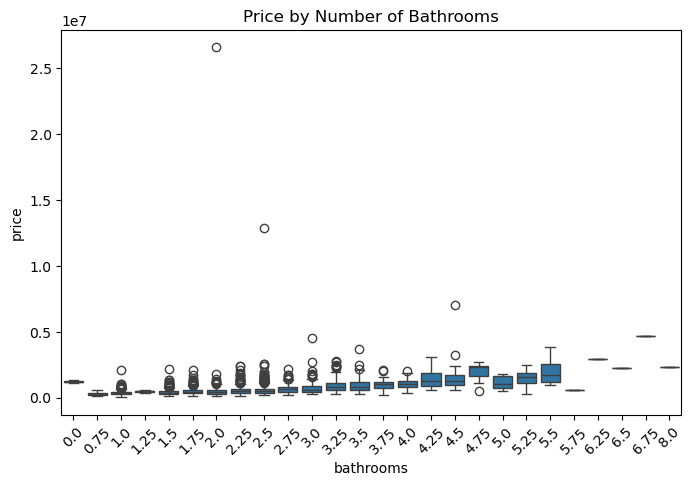

In [103]:
plt.figure(figsize=(8,5))
sns.boxplot(data=a, x="bathrooms", y="price")
plt.title("Price by Number of Bathrooms")
plt.xticks(rotation=45)
plt.show()

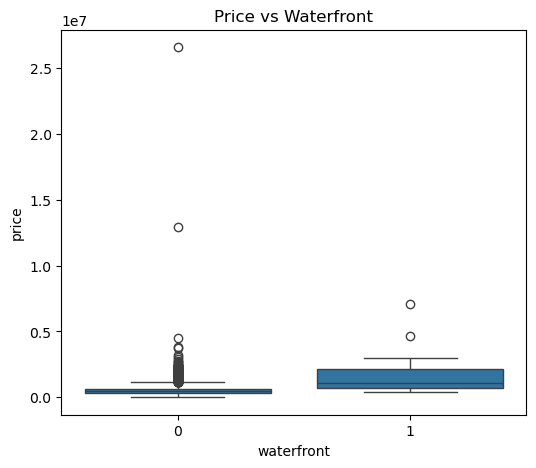

In [104]:
plt.figure(figsize=(6,5))
sns.boxplot(data=a, x="waterfront", y="price")
plt.title("Price vs Waterfront")
plt.show()

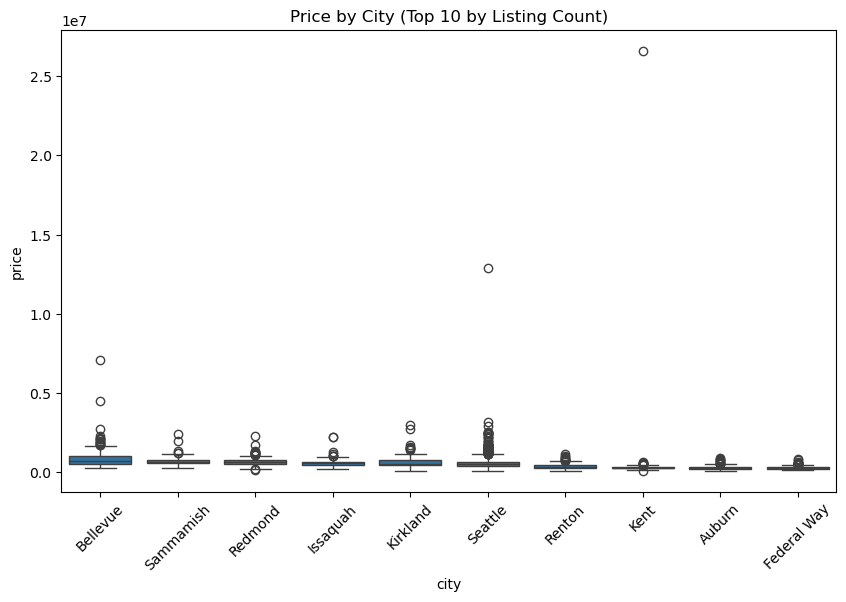

In [105]:
top_cities = a["city"].value_counts().nlargest(10).index
city_order = a[a["city"].isin(top_cities)].groupby("city")["price"].median().sort_values(ascending=False).index

plt.figure(figsize=(10,6))
sns.boxplot(data=a[a["city"].isin(top_cities)], x="city", y="price", order=city_order)
plt.title("Price by City (Top 10 by Listing Count)")
plt.xticks(rotation=45)
plt.show()

In [106]:
a.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,city,statezip,house_age,was_renovated
0,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,Shoreline,WA 98133,59,1
1,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,Seattle,WA 98119,93,0
2,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,Kent,WA 98042,48,0
3,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,Bellevue,WA 98008,51,0
4,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,Redmond,WA 98052,38,1


In [107]:
a = pd.get_dummies(a, columns=['statezip'], drop_first=True)
a = pd.get_dummies(a, columns=['city'], drop_first=True)
a.sample(5)

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,...,city_SeaTac,city_Seattle,city_Shoreline,city_Skykomish,city_Snoqualmie,city_Snoqualmie Pass,city_Tukwila,city_Vashon,city_Woodinville,city_Yarrow Point
3692,383962.0,4.0,2.50,2700,6998,2.0,0,0,3,2700,...,False,False,False,False,False,False,True,False,False,False
1877,275000.0,2.0,1.00,770,8149,1.0,0,0,5,770,...,False,False,True,False,False,False,False,False,False,False
2522,269950.0,3.0,2.50,1890,4838,2.0,0,0,3,1730,...,False,False,False,False,False,False,True,False,False,False
3768,1640000.0,3.0,3.25,3140,5445,2.0,0,3,4,2240,...,False,True,False,False,False,False,False,False,False,False
1754,193000.0,3.0,1.50,1180,9048,1.0,0,0,3,1180,...,False,False,False,False,False,False,False,False,False,False


In [108]:
X = a.drop(columns=['price'])
y = a['price']

xtr, xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42)

xtr.shape, xte.shape, ytr.shape, yte.shape

((3640, 133), (911, 133), (3640,), (911,))

In [109]:
# # ---- Outlier clipping on FEATURES: learn IQR bounds from xtr only, apply to both ----
feature_num_cols = xtr.select_dtypes(include='number').columns

# clip_bounds = {}
# for col in feature_num_cols:
#     Q1 = xtr[col].quantile(0.25)
#     Q3 = xtr[col].quantile(0.75)
#     IQR = Q3 - Q1
#     lower = Q1 - 1.5 * IQR
#     upper = Q3 + 1.5 * IQR
#     clip_bounds[col] = (lower, upper)

#     xtr[col] = xtr[col].clip(lower, upper)
#     xte[col] = xte[col].clip(lower, upper)   # same bounds learned from train

In [110]:
# # ---- Outlier clipping on the TARGET: learn bounds from ytr only, apply to both ----
# Q1, Q3 = ytr.quantile(0.25), ytr.quantile(0.75)
# IQR = Q3 - Q1
# y_lower, y_upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

# ytr = ytr.clip(y_lower, y_upper)
# yte = yte.clip(y_lower, y_upper)

In [111]:
skewed_cols = [col for col in feature_num_cols if abs(xtr[col].skew()) > 1]
print("Skewed feature columns:", skewed_cols)

Skewed feature columns: ['sqft_living', 'sqft_lot', 'waterfront', 'view', 'sqft_above', 'sqft_basement']


In [112]:
pt_features = PowerTransformer(method='yeo-johnson')
if skewed_cols:
    xtr[skewed_cols] = pt_features.fit_transform(xtr[skewed_cols])
    xte[skewed_cols] = pt_features.transform(xte[skewed_cols])

In [113]:
pt_target = PowerTransformer(method='yeo-johnson')

ytr_arr = pt_target.fit_transform(ytr.values.reshape(-1, 1)).ravel()
yte_arr = pt_target.transform(yte.values.reshape(-1, 1)).ravel()

ytr = pd.Series(ytr_arr, index=ytr.index, name='price')
yte = pd.Series(yte_arr, index=yte.index, name='price')

In [114]:

scaler = StandardScaler()

xtr = scaler.fit_transform(xtr)
xte = scaler.transform(xte)

**Note on interpreting results below:** `ytr`/`yte` are on the power-transformed
scale, not raw dollars. R2 is scale-invariant so it's still meaningful as-is, but if
you want predictions back in real dollars, inverse-transform them:

```python
y_pred_real = pt_target.inverse_transform(y_pred.reshape(-1, 1)).ravel()
```

In [115]:
def evaluate_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    from sklearn.model_selection import cross_val_score
    scores = cross_val_score(model, xtr, ytr, cv=5, scoring='r2')
    print("croos val score :",scores.mean(), scores.std())
    print(f"R² Score : {r2:.4f}")
    print(f"MSE      : {mse:.4f}")
    print(f"MAE      : {mae:.4f}")
    print(f"RMSE     : {rmse:.4f}")


In [116]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
evaluate_model(lr, xtr, xte, ytr, yte)

croos val score : 0.8041776550326871 0.025903856521133427
R² Score : 0.7672
MSE      : 0.2297
MAE      : 0.2889
RMSE     : 0.4793


In [117]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)
evaluate_model(xgb, xtr, xte, ytr, yte)

croos val score : 0.7659324708669792 0.0419333442948767
R² Score : 0.7402
MSE      : 0.2564
MAE      : 0.3286
RMSE     : 0.5063


In [118]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=2
)
evaluate_model(rf, xtr, xte, ytr, yte)

croos val score : 0.7271487181719757 0.045252547556209805
R² Score : 0.7211
MSE      : 0.2752
MAE      : 0.3418
RMSE     : 0.5246


In [119]:
from sklearn.ensemble import GradientBoostingRegressor

model = GradientBoostingRegressor(random_state=42)
evaluate_model(model, xtr, xte, ytr, yte)

croos val score : 0.7324780279321962 0.042222718530256644
R² Score : 0.7164
MSE      : 0.2799
MAE      : 0.3584
RMSE     : 0.5290


In [120]:
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor(n_neighbors=5)
evaluate_model(knn, xtr, xte, ytr, yte)

croos val score : 0.7014391320749785 0.027985417171666895
R² Score : 0.6943
MSE      : 0.3017
MAE      : 0.3603
RMSE     : 0.5493
